In [2]:
import numpy as np

In [3]:
def chirp_mass(m1, m2):
    return (m1*m2)**(3/5) / (m1+m2)**(1/5)

At the leading order the GW signal duration depends on the chirp mass (in detector frame) of the binary, and the considered frequency range:

$$ \Delta t \sim \frac{5}{256} \left( \frac{G \mathcal{M}}{c^3}\right)^{-5/3} \pi^{-8/3} \left(f_{\rm low}^{-8/3} - f_{\rm high}^{-8/3} \right)$$

In [4]:
def gw_duration(m1, m2, f_low, f_high):
    """
    Leading-order inspiral duration IN SECONDS for a binary with component masses m1 and m2, starting at frequency f_low and ending at frequency f_high.
    Masses are in solar masses (in detector frame!), frequencies in Hz.
    """
    # constants
    G = 6.67430e-11
    c = 299792458.0
    Msun = 1.98847e30
    GMsun_c3 = G * Msun / c**3 
    Mc = chirp_mass(m1, m2)

    prefactor = 5 / 256
    tau = prefactor * (GMsun_c3 * Mc)**(-5/3) * np.pi**(-8/3)
    return tau * (f_low**(-8/3) - f_high**(-8/3))

In [5]:
et_low_freq = 6
et_high_freq = 256
mass1 = 1100
mass2 = 1100
print(f"GW signal duration for a {mass1} Msol+{mass2} Msol binary is {np.round(gw_duration(mass1, mass2, et_low_freq, et_high_freq), 3)} seconds.")

GW signal duration for a 1100 Msol+1100 Msol binary is 0.059 seconds.


In [6]:
def gw_duration(Mc, f_low, f_high):
    """
    Leading-order inspiral duration IN SECONDS for a binary with component masses m1 and m2, starting at frequency f_low and ending at frequency f_high.
    Masses are in solar masses (in detector frame!), frequencies in Hz.
    """
    # constants
    G = 6.67430e-11
    c = 299792458.0
    Msun = 1.98847e30
    GMsun_c3 = G * Msun / c**3 
    

    prefactor = 5 / 256
    tau = prefactor * (GMsun_c3 * Mc)**(-5/3) * np.pi**(-8/3)
    return tau * (f_low**(-8/3) - f_high**(-8/3))

In [7]:
et_low_freq = 6
ligo_low_freq = 20
et_high_freq = 256

Mc=16


print(f"ET-GW signal duration for a {Mc} Msol binary is {np.round(gw_duration(Mc, et_low_freq, et_high_freq), 3)} seconds.")
print(f"LIGO-GW signal duration for a {Mc} Msol binary is {np.round(gw_duration(Mc, ligo_low_freq, et_high_freq), 3)} seconds.")

ET-GW signal duration for a 16 Msol binary is 53.572 seconds.
LIGO-GW signal duration for a 16 Msol binary is 2.158 seconds.


In [8]:
def from_mChirp_q_to_m1_m2(mChirp, q):
    """
    Compute the transformation from mChirp, q to m1, m2
    """
    m1 = mChirp * (1 + q)**(1/5) * q**(-3/5)
    m2 = mChirp * (1 + q)**(1/5) * q**(2/5)
    return m1, m2

In [18]:
mchirp_vec = np.array(np.linspace(650, 1000, 200))
mass_ratio_vec = np.array(np.linspace(0.125, 1.0, 200))
mass1 = []
mass2 = []
for mass in mchirp_vec:
    for q in mass_ratio_vec:
        m1, m2 = from_mChirp_q_to_m1_m2(mass, q)
        mass1.append(m1)
        mass2.append(m2)

np.min(mass1), np.max(mass1), np.min(mass2), np.max(mass2)

(746.6539307480729, 3565.2049159320068, 289.6728994194756, 1148.698354997035)

TODO: Create scatter PLot

Text(0, 0.5, 'Mass 2 [Msol]')

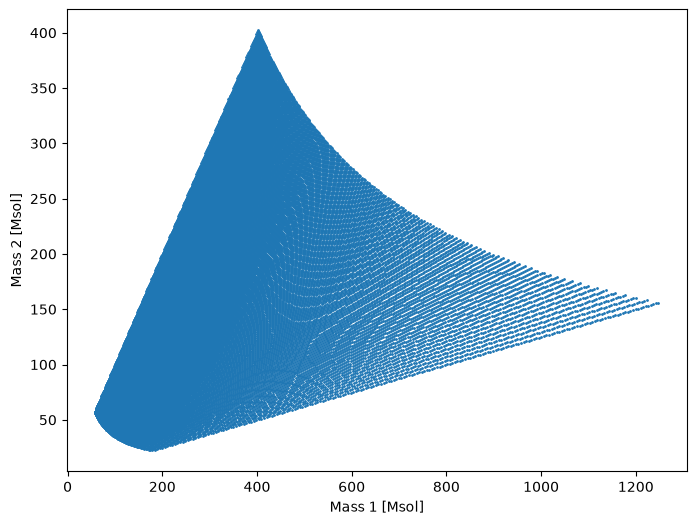

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(mass1, mass2, s=1)
plt.xlabel("Mass 1 [Msol]")
plt.ylabel("Mass 2 [Msol]")